# Лабораторная работа №6. Многоскоростная обработка сигналов.

Лаборатория цифровой обработки сигналов, МФТИ.

В названии файла заменить `familyname` на свою фамилию. Для выполнения задания требуются два сигнала с цифрового осциллографа (см. задачи 1.2 и 2.1).

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt


In [2]:
def dtft(x, M=2048):
    """
    Функция вычисляет значения ДВПФ в M точках на отрезке
    по оси нормированных частот [-0.5; 0.5]

    Parameters
    ----------
    x : complex
        входная последовательность отсчетов, первый отсчет при k=0
    M : int
        колличество точек на отрезке [-0.5; 0.5]

    Returns
    -------
    float
        значения оси нормированных частот,
        соотвествующих вычисленным значениям
        спектральной функции
    complex
        значения спектральной функции
    """
    return (np.fft.fftshift(np.fft.fftfreq(M, d=1)), np.fft.fftshift(np.fft.fft(x, M)))
def oscilloscope_file_read(file, const_level=0):
    f = open(file)
    str1 = f.read().split('\n')
    f.closed

    figsize=[8, 4]

    # dt
    val, unit = str1[1].replace(',', '.').split(' ')[3:5]
    val=float(val)
    if unit=='uS':
        val*=1e-6
    elif unit=='nS':
        val*=1e-9
    elif unit=='mS':
        val*=1e-3
    fs = int(1.0 / val)

    #Voltage step
    val, unit = str1[2].replace(',', '.').split(' ')[3:5]
    dv=float(val)
    if unit=='mV':
        dv*=1e-3


    # Zero level
    zero_level= int(str1[3].split(' ')[3])
    str_num = len(str1)
    signal_lev = np.empty(shape=(str_num-8), dtype=float)
    for k, u in enumerate(range(7, str_num-1, 1)):
        data = str1[u].split()
        signal_lev[k]=(int(data[1])-zero_level)*dv-const_level
    return fs, signal_lev

def analyse(fs, signal_lev, window='boxcar', stem_signal=False):
    figsize=[8,4]
    plt.rcParams['font.size'] = '12'
    window = signal.get_window(window, Nx=len(signal_lev), fftbins=True)
    signal_lev = signal_lev*window
    plt.figure(figsize=figsize)
    if stem_signal:
        plt.stem(np.arange(signal_lev.size)/fs*1e3, signal_lev, markerfmt='.')
    else:
        plt.plot(np.arange(signal_lev.size)/fs*1e3, signal_lev, '.-')
    plt.title("Сигнал")
    plt.xlabel("$t$, мc")
    plt.ylabel("$x(k\Delta t)w[k]$, В")
    plt.grid()
    plt.tight_layout()
    Xn = np.fft.fftshift(np.fft.fft(signal_lev, 2**18))
    f = fs*np.linspace(-0.5, 0.5, num=Xn.size, endpoint=False)
#     plt.show()

    plt.figure(figsize=figsize)
    plt.title("ДВПФ (модуль), линейный масштаб")
    plt.plot(f/1e3, abs(Xn))
    plt.grid()
    plt.xlabel("$f$, кГц")
    plt.ylabel("$|X(f)|$")
    plt.tight_layout()
#     plt.show()

    plt.figure(figsize=figsize)
    maxXn=max(abs(Xn))
    plt.title("ДВПФ (модуль), дБ")
    plt.plot(f/1e3, 20*np.log10(abs(Xn)/maxXn))
    plt.grid()
    plt.xlabel("$f$, кГц")
    plt.ylabel("АЧХ, дБ")
    plt.tight_layout()
#     plt.show()

def plot_signal_and_dtft(x, fs, signal_name="x", k_lim=None, use_normalized_freq=True):
    if k_lim is None:
        k_lim=[0, len(x)]
    # График сигнала
    plt.figure(figsize=(12, 3))
    plt.stem(x, markerfmt=".")
    plt.xlabel("$k$")
    plt.ylabel("$%s[k]$" %signal_name)
    plt.grid()
    plt.xlim(k_lim)
    plt.title("Сигнал $%s[k]$, $f_s=$%i кГц" %(signal_name, fs/1000))
    plt.show()
    # График модуля ДВПФ
    plt.figure(figsize=(12, 3))
    freq, X = dtft(x, M=2048)

    if use_normalized_freq:
        plt.xlabel("$\\nu$")
        plt.ylabel("$|%s(\\nu)|$" %(signal_name.upper()))
    else:
        freq = freq * fs * 1e-3
        plt.xlabel("$f$, кГц")
        plt.ylabel("$|%s(f)|$" %(signal_name.upper()))
    plt.plot(freq, abs(X))
    plt.xlim((freq[0], freq[-1]))
    plt.grid()
    plt.title("ДВПФ сигнала $%s[k]$ (модуль)" %signal_name)
    plt.show()

def plot_filter_characteristics(x, fs, use_normalized_freq=True, unwrapping=True, ideal_cutoff_normalized=None, ideal_k_pass=1):
    # Импульсная характеристика
    plt.figure(figsize=(12, 3))
    plt.stem(x, markerfmt=".")
    plt.xlabel("$k$")
    plt.ylabel("$h[k]$")
    plt.grid()
    plt.title("Импульсная характеристика $h[k]$, $f_s=$%i кГц" %(fs/1000))
    plt.show()
    # АЧХ
    plt.figure(figsize=(12, 3))
    freq, X = dtft(x, M=2048)
    dl=1e-4

    ideal_mag = np.array([-0.5, -ideal_cutoff_normalized-dl, -ideal_cutoff_normalized+dl,
                          ideal_cutoff_normalized-dl, ideal_cutoff_normalized+dl, 0.5])

    if use_normalized_freq:
        plt.xlabel("$\\nu$")
        plt.ylabel("$|H(\\nu)|$")
    else:
        freq = freq * fs * 1e-3
        plt.xlabel("$f$, кГц")
        plt.ylabel("$|H(f)|$")
        ideal_mag *= fs * 1e-3


    plt.plot(ideal_mag, [0, 0, ideal_k_pass, ideal_k_pass, 0, 0], '--r')
    plt.plot(freq, abs(X))
    plt.xlim((freq[0], freq[-1]))
    plt.grid()
    plt.title("AЧХ")
    plt.show()
    # ФЧХ
    plt.figure(figsize=(12, 3))
    if use_normalized_freq:
        plt.xlabel("$\\nu$")
        plt.ylabel("$\\varphi(\\nu)$, рад")
    else:
        plt.xlabel("$f$, кГц")
        plt.ylabel("$\\varphi(f)$, рад")
    if unwrapping:
        plt.plot(freq, np.unwrap(np.angle(X)))
        plt.title("ФЧХ (с разверткой)")
    else:
        plt.plot(freq, np.angle(X))
        plt.title("ФЧХ (без развертки)")
    plt.xlim((freq[0], freq[-1]))
    plt.grid()

    plt.show()


In [3]:
%matplotlib inline
%matplotlib widget


# Модуль 1. Интерполяция сигналов.

## Задача 1.1. Интерполяция сигналов с помощью ДПФ.

|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| $N$   |  16 |  16 |  16 |  16 |  16 |  30 |  30 |  30 |  30 |   30 |   20 |   20 |   20 |   20 |   20 |   32 |   32 |   32 |   32 |   32 |
| $A_1$ |   2 |   3 |   4 |   5 |   6 |   2 |   3 |   4 |   5 |    6 |    2 |    3 |    4 |    5 |    6 |    2 |    3 |    4 |    5 |    6 |
| $n_1$ |   3 |   4 |   5 |   6 |   7 |   3 |   4 |   5 |   6 |    7 |    3 |    4 |    5 |    6 |    7 |    3 |    4 |    5 |    6 |    7 |
| $A_2$ |   3 |   5 |   1 |   2 |   5 |   3 |   5 |   1 |   2 |    5 |    3 |    5 |    1 |    2 |    5 |    3 |    5 |    1 |    2 |    5 |
| $n_2$ |   7 |   5 |   7 |   4 |   2 |   7 |   5 |   7 |   4 |    2 |    7 |    5 |    7 |    4 |    2 |    7 |    5 |    7 |    4 |    2 |

Пусть некоторый периодический сигнал $y(t)$ был дискретизован в соответствии с теоремой Котельникова,  $x[k]$ — один период получившейся последовательности отсчетов:
 $$ x[k] = A_1\cos{\left (2\pi\dfrac{n_1}{N} k \right )} + A_2 \cos{\left (2\pi\dfrac{n_2}{N} k \right )}.$$
Произведите интерполяцию с коэффициентом $L=5$ путем добавления нулей в середину ДПФ сигнала $x[k]$. Объясните, почему восстановление сигнала в данном случае точное.

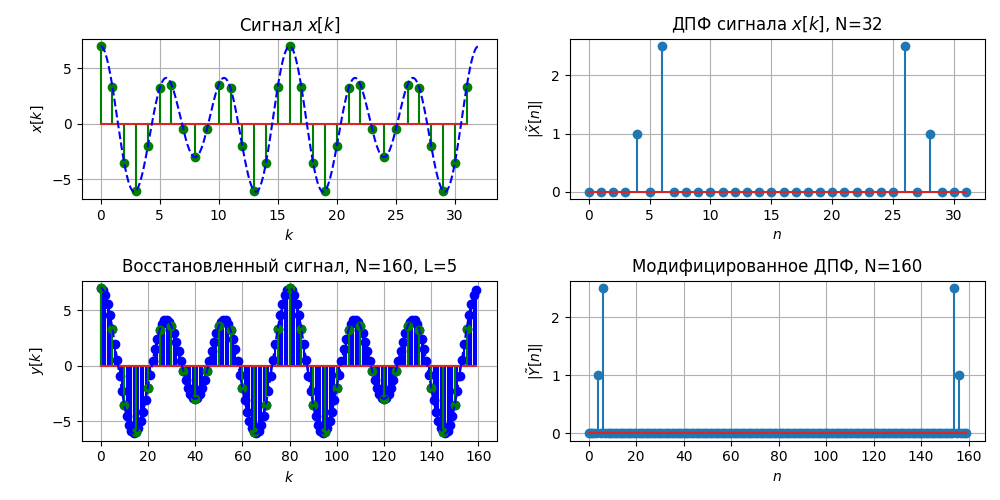

In [4]:
# Настроить параметры для своего сигнала (вариант Ц: N=32, A1=5, n1=6, A2=2, n2=4)
N=32
x=np.ones(N)
n_1=6
n_2=4
A_1=5
A_2=2
L=5

k = np.arange(N)
x = A_1 * np.cos(2*np.pi*n_1*k/N) + A_2 * np.cos(2*np.pi*n_2*k/N)

Q=1024
k1=np.arange(Q)
q = A_1 * np.cos(2*np.pi*n_1*k1/Q) + A_2 * np.cos(2*np.pi*n_2*k1/Q)

plt.figure(figsize=[10, 5], dpi=100)
plt.subplot(2,2,1)
plt.stem(np.arange(x.size), x, 'g', markerfmt='go')
plt.plot(N*np.arange(q.size)/Q, q, 'b--')
plt.title(u'Сигнал $x[k]$')
plt.xlabel(u'$k$')
plt.ylabel(u'$x[k]$')
plt.grid()

Xn=np.fft.fft(x, N)/N
plt.subplot(2,2,2)
plt.stem(np.arange(N), abs(Xn))
plt.title(u'ДПФ сигнала $x[k]$, N=%i' %N);
plt.xlabel(u'$n$');
plt.ylabel(u'$|\\tilde{X}[n]|$');
plt.grid()

if (N%2)==0:
    Yn=np.hstack((Xn[0:(N//2)], Xn[N//2]/2, np.zeros((L-1)*N-1),
                     Xn[N//2]/2, Xn[(N//2+1):N]))
#elif (N%2)!=0:
#    add code

plt.subplot(2,2,4)
plt.stem(np.arange(Yn.size), abs(Yn))
plt.title(u'Модифицированное ДПФ, N=%i' %(Yn.size));
plt.xlabel(u'$n$');
plt.ylabel(u'$|\\tilde{Y}[n]|$');
plt.grid()

x2=np.fft.ifft(Yn)*L*N
plt.subplot(2,2,3)
plt.stem(np.arange(x2.size), x2.real,'b', markerfmt='bo')
plt.stem(Yn.size*np.arange(x.size)/N, x, 'g', markerfmt='go')
plt.plot(L*N*np.arange(q.size)/Q, q, 'b--')
plt.title(u'Восстановленный сигнал, N=%i, L=%i' %(Yn.size, L))
plt.xlabel(u'$k$')
plt.ylabel(u'$y[k]$')
plt.grid()
plt.tight_layout()
plt.show()


Восстановление сигнала при помощи интерполяции получается точное, так как:
1) рассматривается строго один период периодической функции - частоты попадают точно в бины ДПФ;
2) отсутствует наложение, так как сигнал изначально дискретизован с теоремой Котельникова, а в ходе интерполяции частота дискретизации только повышается;

## Задача 1.2. Система однократной интерполяции.

|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| $f_0$, кГц  |  25 |  22 |  23 |  26 |  28 |  25 |  22 |  23 |  26 |   28 |   25 |   22 |   23 |   26 |   28 |   25 |   22 |   23 |   26 |   28 |
| $f_m$, кГц  |  10 |  10 |  10 |  10 |  10 |   9 |   9 |   9 |   9 |    9 |    8 |    8 |    8 |    8 |    8 |    7 |    7 |    7 |    7 |    7 |
| Коэф. АМ, % |  80 |  70 |  80 |  70 |  80 |  70 |  80 |  70 |  80 |   70 |   80 |   70 |   80 |   70 |   80 |   70 |   80 |   70 |   80 |   70 |
| $f_{д}$, кГц  | 200 | 200 | 200 | 200 | 200 | 200 | 200 | 200 | 200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |
| $L$         |   3 |   4 |   5 |   3 |   4 |   5 |   4 |   3 |   4 |    5 |    3 |    4 |    5 |    3 |    4 |    5 |    4 |    3 |    4 |    5 |

Промоделируйте работу системы однократной интерполяции с коэффициентом $L$ с помощью функции ``scipy.signal.upfirdn()`` при подаче на ее вход нескольких первых отсчетов (составляющих примерно один период) амплитудно модулированного сигнала с цифрового осциллографа с параметрами из таблицы. 

1. Обоснуйте Ваш выбор КИХ-фильтра для системы интерполяции. Изобразите на графиках его импульсную характеристику $h[k]$, АЧХ и ФЧХ.

2. Постройте графики, иллюстрирующие работу системы интерполяции во временной области:

* а) входного сигнала $x[k]$,

* б) сигнала $q[k]$, получаемого добавлением $L-1$ отсчета между каждой парой исходных отсчетов,

* в) выходного сигнала $y[k]$.

3. Постройте графики модуля ДВПФ последовательностей $x[k]$, $h[k]$, $q[k]$ и $y[k]$, иллюстрирующих работу системы интерполяции в частотной области.

4. Укажите шаг и частоту дискретизации выходного сигнала системы интерполяции. 



In [5]:
# выбор коэффициента интерполяции
L=4


In [6]:
# чтение сигнала
fs, x = oscilloscope_file_read(file="Data/gen/6-1-2.txt", const_level=0)
fs


200000

In [7]:
print("частота дискретизации исходного сигнала", fs/1e6, " МГц.")
print("шаг дискретизации исходного сигнала", 1e6/fs, " мкс.")
print("частота дискретизации на выходе системы интерполяции", fs*L/1e6, " МГц.")
print("шаг дискретизации на выходе системы интерполяции", 1e6/(fs*L), " мкс.")


частота дискретизации исходного сигнала 0.2  МГц.
шаг дискретизации исходного сигнала 5.0  мкс.
частота дискретизации на выходе системы интерполяции 0.8  МГц.
шаг дискретизации на выходе системы интерполяции 1.25  мкс.


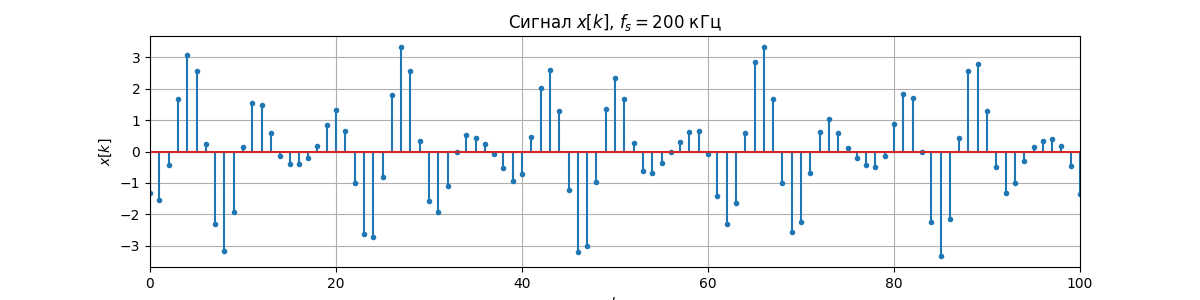

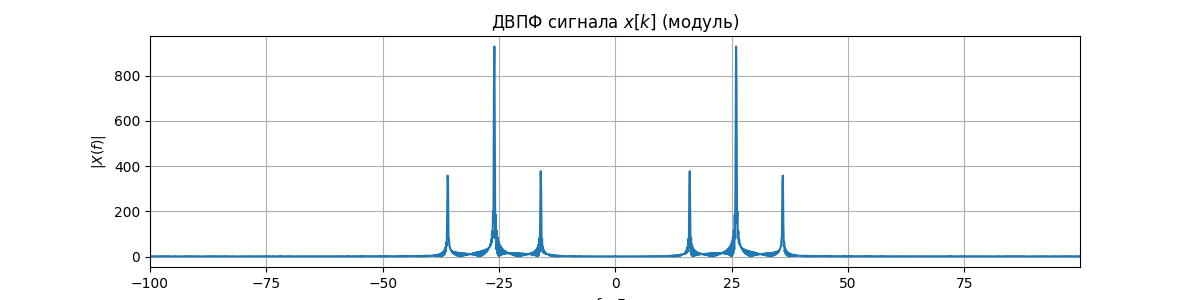

In [8]:
plot_signal_and_dtft(x, fs, signal_name="x", k_lim=[0, 100], use_normalized_freq=False)


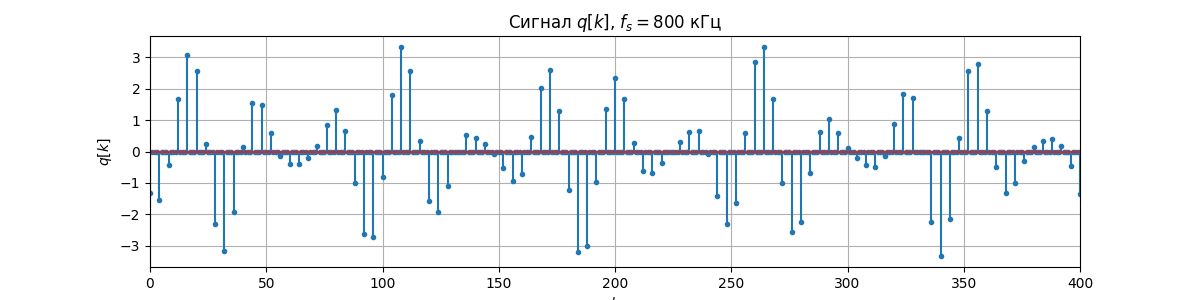

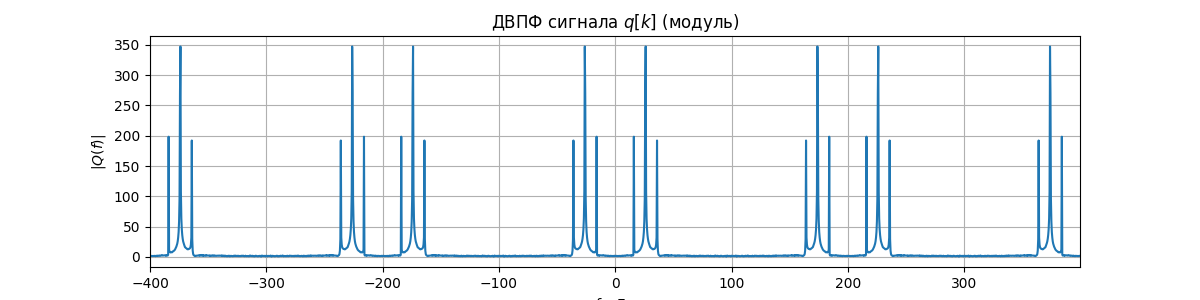

In [9]:
# добавление нулей (upfirdn без фильтрации)
q=signal.upfirdn([1], x, up=L)   # FIR filter
plot_signal_and_dtft(q, fs*L, signal_name="q", k_lim=[0, 100*L], use_normalized_freq=False)


In [10]:
# выбор фильтра
N=40
nu1=1/(2*L)-0.02 #0.05
nu2=1/(2*L)+0.02 #0.05
bands = np.array([0, nu1, nu2, 0.5])
desired = np.array([L, 0])
weight = np.array([1, 1])
h = signal.remez(numtaps=N, bands=bands, desired=desired, weight=weight, fs=1)


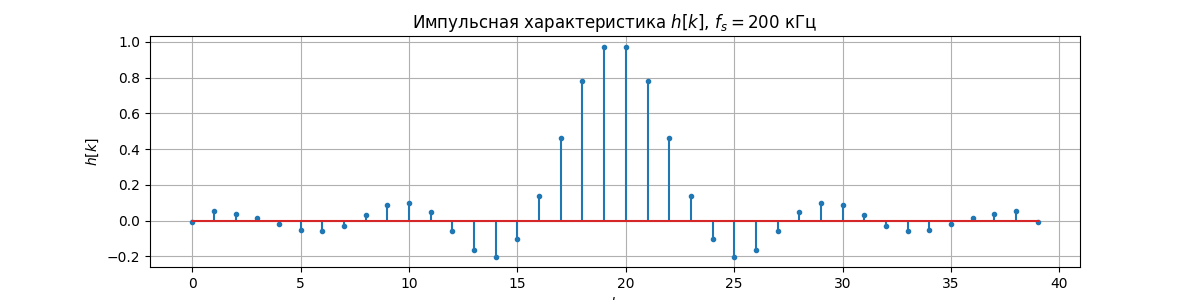

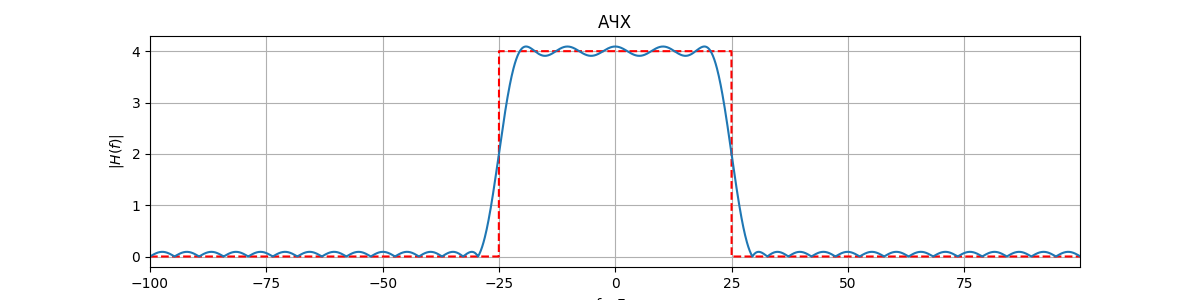

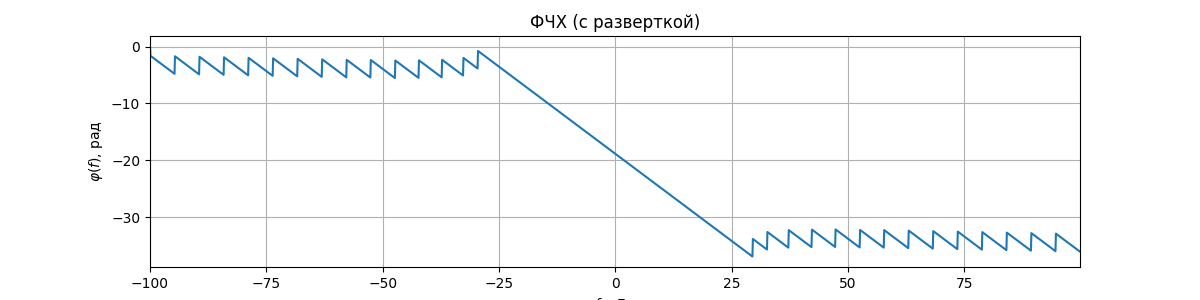

In [11]:
plot_filter_characteristics(h, fs, use_normalized_freq=False, unwrapping=True, ideal_cutoff_normalized=1.0/(2.0*L), ideal_k_pass=L)
# сравните графики при разном выборе параметров use_normalized_freq и unwrapping

# use_normalized_freq отвечает за нормирование частот (частоты в кГц либо безразмерные)
# unwrapping отвечает за развертку фазы (убираются или нет скачки на 2pi)


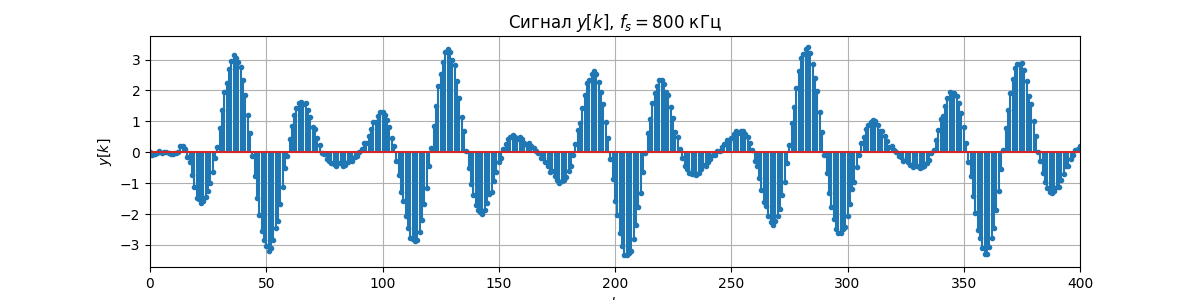

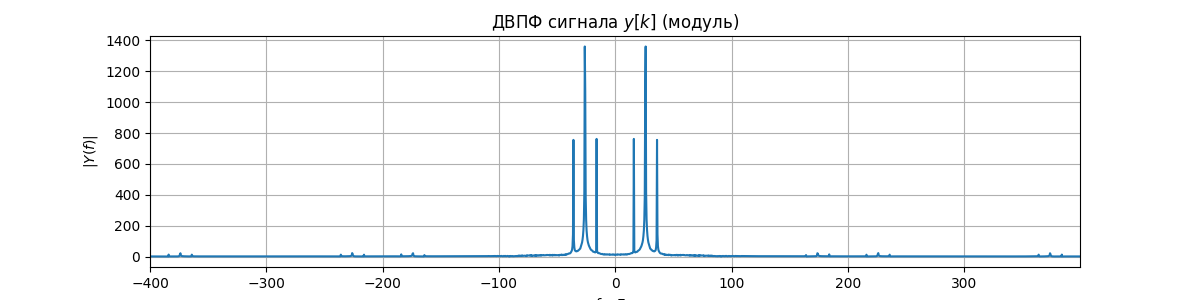

In [12]:
# Сигнал после интерполяции
y=signal.upfirdn(h, x, up=L)   # FIR filter
plot_signal_and_dtft(y, fs*L, signal_name="y", k_lim=[0, 100*L], use_normalized_freq=False)


Амплитуда выходного сигнала в L=4 раз больше, чем амплитуда входного сигнала системы интерполяции.

## Задача 1.3. Интерполяция первого и нулевого порядка.

Повторите вычисления задачи 1.2 для КИХ-фильтров с импульсными характеристиками ${{h}_{0}}[k]$ и ${{h}_{1}}[k]$ и $L=2$. Сравните результаты.

${{h}_{0}}[k]=\left\{ \begin{matrix}
   1,\ \ \text{ при }k=0,\ \ 1,  \\
   0,\ \ \text{ при других }k.  \\
\end{matrix} \right.$

${{h}_{1}}[k]=\left\{ \begin{matrix}
   0,5,\ \ \text{ при }k=0,\ \ 2,  \\
   1,\ \ \text{ при }k=1,  \\
   0,\ \ \text{ при других  }k.  \\
\end{matrix} \right.$



In [13]:
# использовать код из задачи 1.2, выбирая правильные параметры h и L
L = 2


In [14]:
h0 = np.zeros(N)
h0[0:2] = 1
#ступенчатая интерполяция (дублирование предыдущего известного отсчета)


In [15]:
h1 = np.zeros(N)
h1[0:3]= 0.5
h1[1] = 1
#линейная интерполяция (среднее арифметическое соседних отсчетов)


In [16]:
# чтение сигнала
fs, x = oscilloscope_file_read(file="Data/gen/6-1-2.txt", const_level=0)


In [17]:
print("частота дискретизации исходного сигнала", fs/1e6, " МГц.")
print("шаг дискретизации исходного сигнала", 1e6/fs, " мкс.")
print("частота дискретизации на выходе системы интерполяции", fs*L/1e6, " МГц.")
print("шаг дискретизации на выходе системы интерполяции", 1e6/(fs*L), " мкс.")


частота дискретизации исходного сигнала 0.2  МГц.
шаг дискретизации исходного сигнала 5.0  мкс.
частота дискретизации на выходе системы интерполяции 0.4  МГц.
шаг дискретизации на выходе системы интерполяции 2.5  мкс.


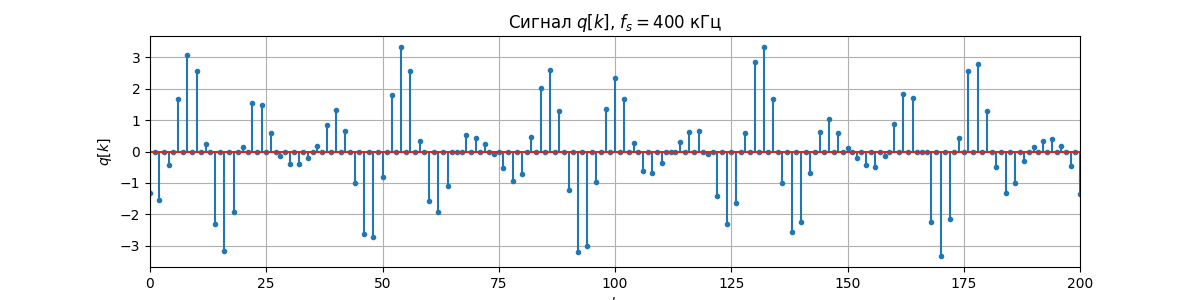

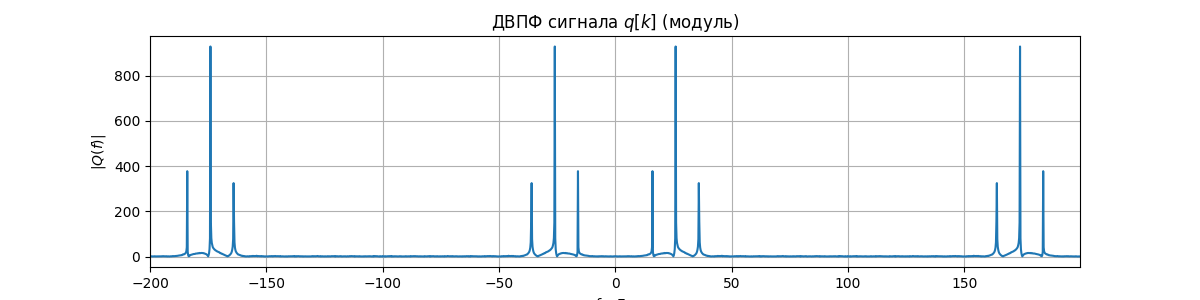

In [18]:
# добавление нулей (upfirdn без фильтрации)
q=signal.upfirdn([1], x, up=L)   # FIR filter
plot_signal_and_dtft(q, fs*L, signal_name="q", k_lim=[0, 100*L], use_normalized_freq=False)


In [19]:
# выбор фильтра
N=40
nu1=1/(2*L)-0.02 #0.05
nu2=1/(2*L)+0.02 #0.05
bands = np.array([0, nu1, nu2, 0.5])
desired = np.array([L, 0])
weight = np.array([1, 1])
h = signal.remez(numtaps=N, bands=bands, desired=desired, weight=weight, fs=1)


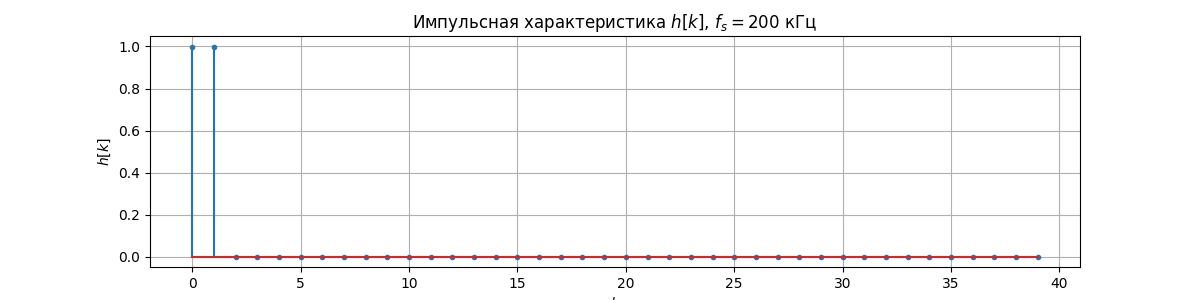

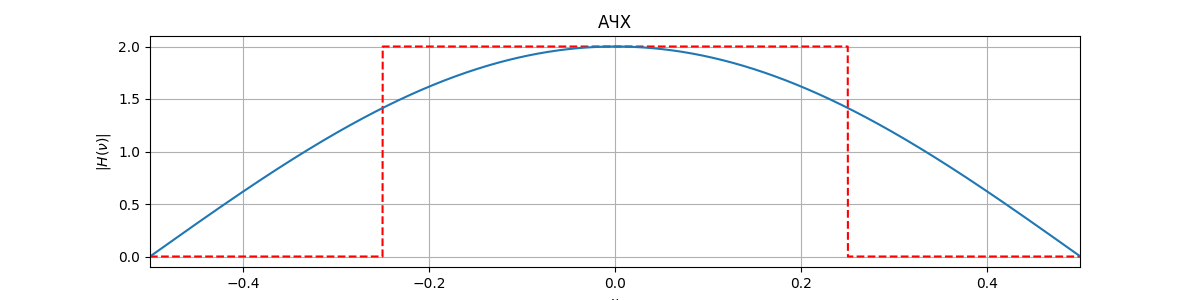

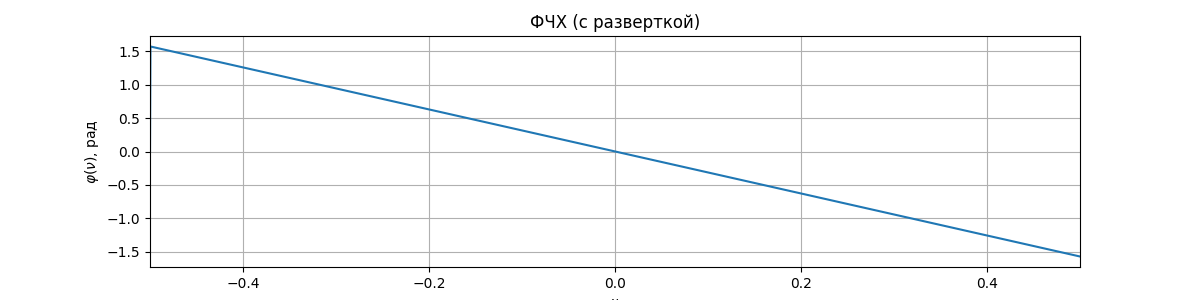

In [20]:
plot_filter_characteristics(h0, fs, use_normalized_freq=True, unwrapping=True, ideal_cutoff_normalized=1.0/(2.0*L), ideal_k_pass=L)


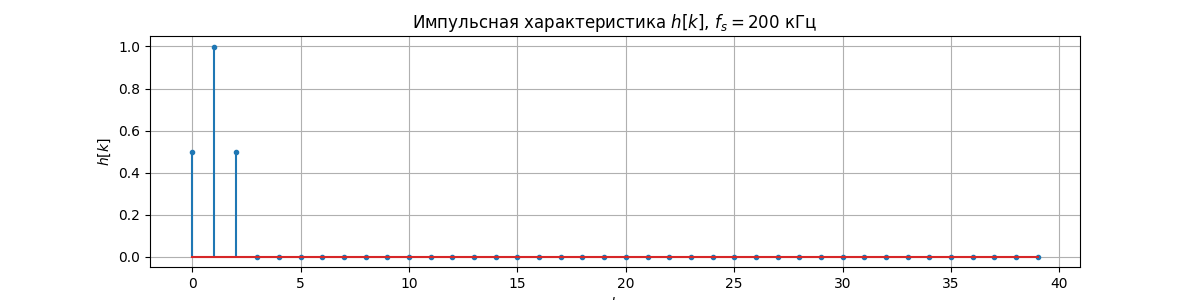

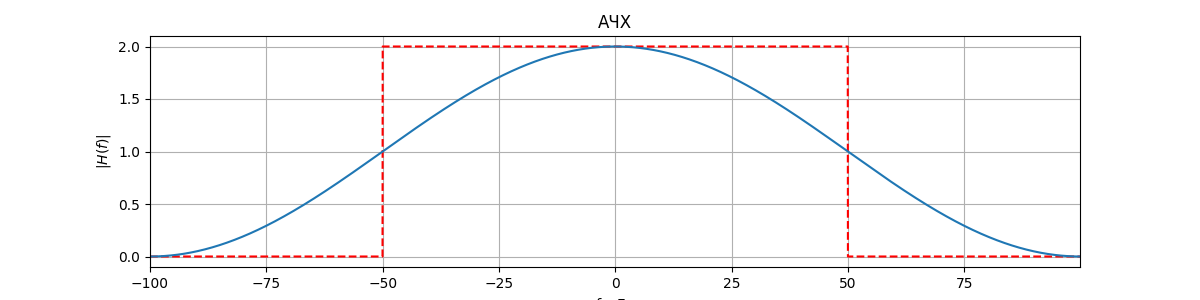

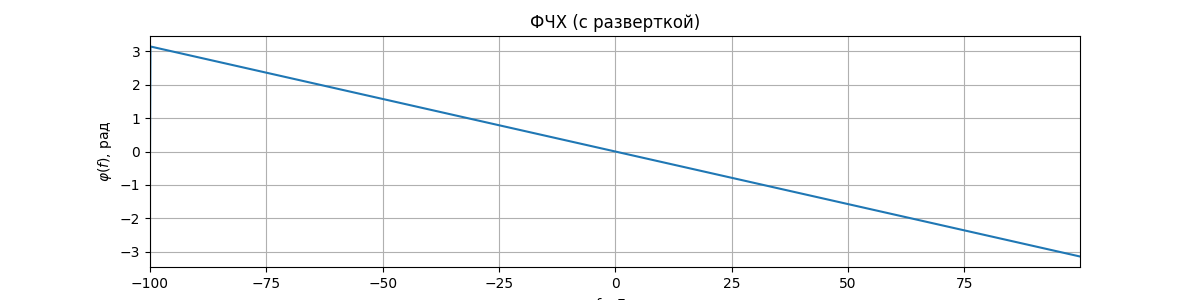

In [21]:
plot_filter_characteristics(h1, fs, use_normalized_freq=False, unwrapping=True, ideal_cutoff_normalized=1.0/(2.0*L), ideal_k_pass=L)


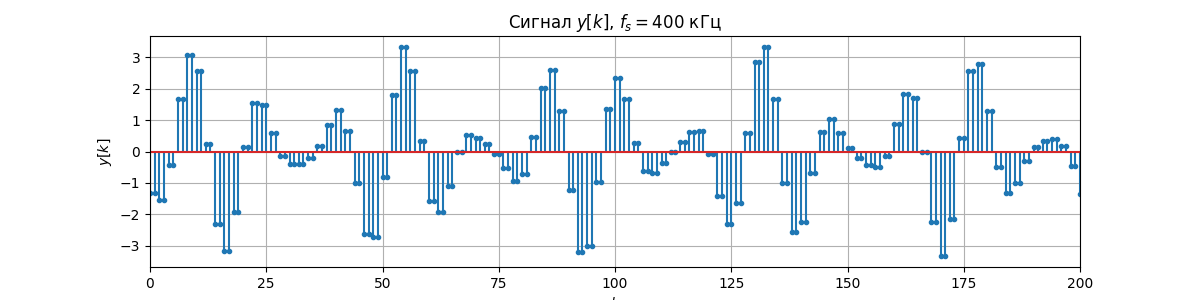

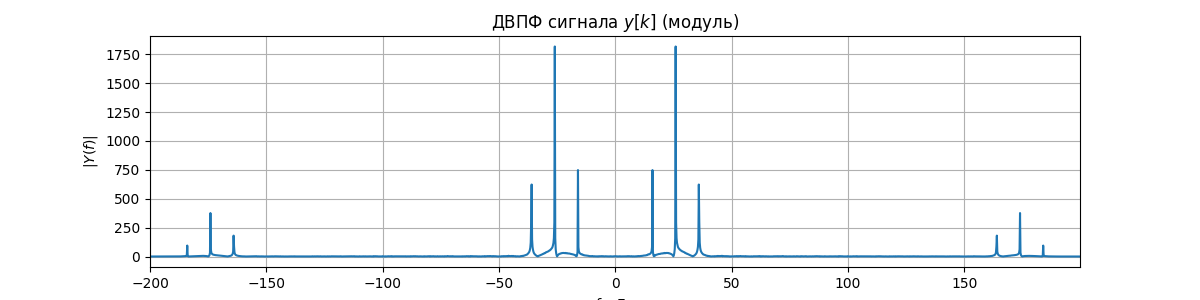

In [22]:
# Сигнал после интерполяции
y=signal.upfirdn(h0, x, up=L)   # FIR filter
plot_signal_and_dtft(y, fs*L, signal_name="y", k_lim=[0, 100*L], use_normalized_freq=False)


/tmp/ipykernel_41233/2945728172.py:99: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 3))


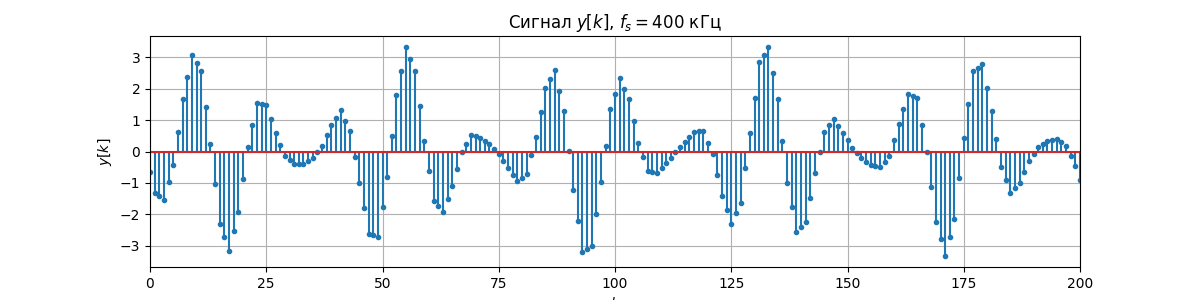

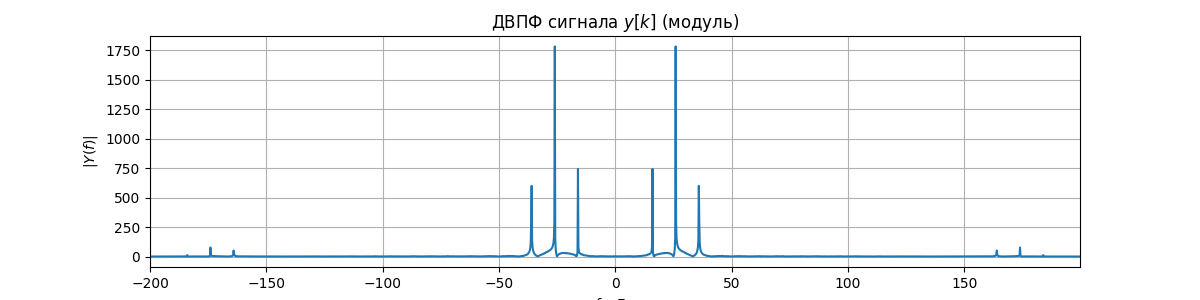

In [23]:
y=signal.upfirdn(h1, x, up=L)   # FIR filter
plot_signal_and_dtft(y, fs*L, signal_name="y", k_lim=[0, 100*L], use_normalized_freq=False)


#  Модуль 2. Прореживание сигналов и передискретизация с рациональным шагом.

## Задача 2.1. Система однократной децимации.

|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| $f_0$, кГц |  80 |  90 | 100 | 110 | 120 | 130 | 140 | 150 | 160 |  170 |  180 |  190 |  200 |  210 |  220 |  230 |  240 |  250 |  260 |  270 |
| $f_д$, МГц |  10 |  20 |  10 |  20 |  10 |  20 |  10 |  20 |  10 |   20 |   10 |   20 |   10 |   20 |   10 |   20 |   10 |   20 |   10 |   20 |
| $M$        |   5 |  10 |   5 |  10 |   5 |  10 |   5 |  10 |   5 |   10 |    5 |   10 |    5 |   10 |    5 |   10 |    5 |   10 |    5 |   10 |

Промоделируйте работу системы однократной децимации с коэффицентом $M$ при подаче на ее вход нескольких первых отсчетов синусоидального сигнала с цифрового осциллографа с параметрами из таблицы. 

1. Обоснуйте Ваш выбор фильтра для системы децимации. Изобразите на графиках его импульсную характеристику $h[k]$, АЧХ и ФЧХ.

2. Постройте графики, иллюстрирующие работу системы интерполяции во временной области:

* а) входного сигнала $x[k]$,

* б) выходного сигнала $y[k]$.

3. Постройте графики модуля ДВПФ последовательностей $x[k]$ и $y[k]$, иллюстрирующих работу системы интерполяции во частотной области.

4. Укажите шаг и частоту дискретизации выходного сигнала системы. 

In [24]:
# выбор коэффициентов
L = 1 # для децимации L = 1
M = 5


In [25]:
# чтение сигнала
fs, x = oscilloscope_file_read(file="Data/gen/6-2-1.txt", const_level=0)
fs


10000000

In [26]:
print("частота дискретизации исходного сигнала", fs/1e6, " МГц.")
print("шаг дискретизации исходного сигнала", 1e6/fs, " мкс.")
print("частота дискретизации на выходе системы децимации", fs*L/M/1e6, " МГц.")
print("шаг дискретизации на выходе системы децимации", 1e6/(fs*L/M), " мкс.")


частота дискретизации исходного сигнала 10.0  МГц.
шаг дискретизации исходного сигнала 0.1  мкс.
частота дискретизации на выходе системы децимации 2.0  МГц.
шаг дискретизации на выходе системы децимации 0.5  мкс.


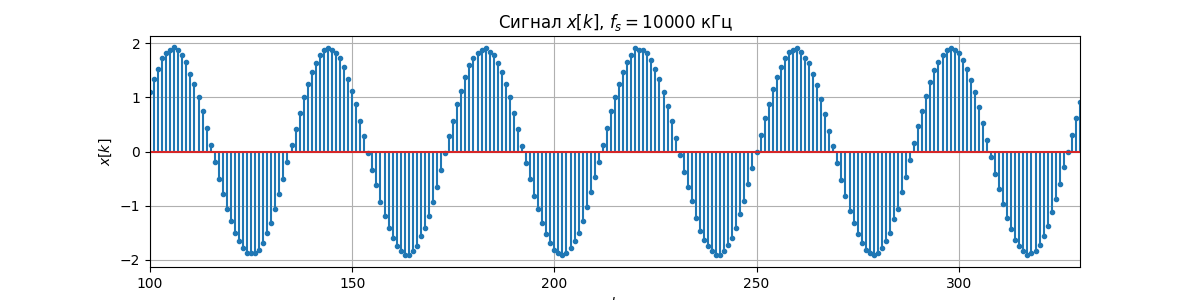

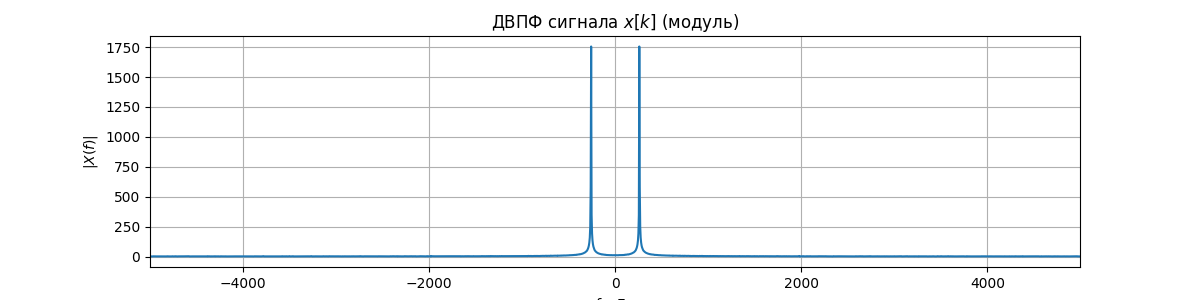

In [27]:
plot_signal_and_dtft(x, fs, signal_name="x", k_lim=[100, 330], use_normalized_freq=False)


In [28]:
# выбор фильтра
N=40
ideal_cutoff_normalized = min(1/(2*L), 1/(2*M))
nu1 = ideal_cutoff_normalized - 0.02 #0.05
nu2 = ideal_cutoff_normalized + 0.02 #0.05
bands = np.array([0, nu1, nu2, 0.5])
desired = np.array([L, 0])
weight = np.array([1, 1])
h = signal.remez(numtaps=N, bands=bands, desired=desired, weight=weight, fs=1)


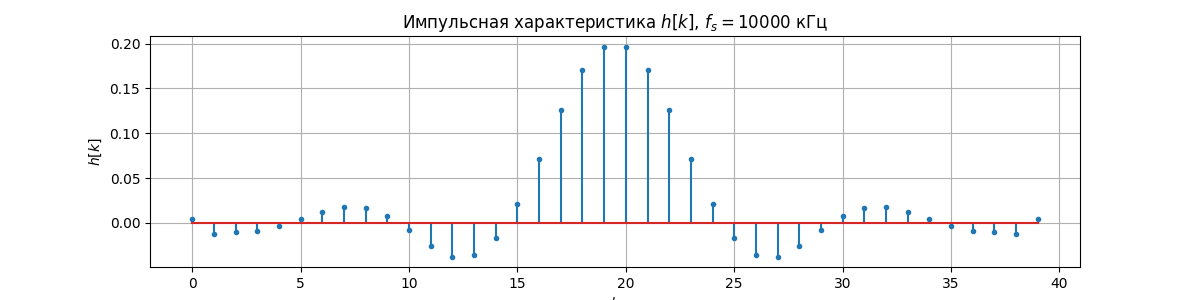

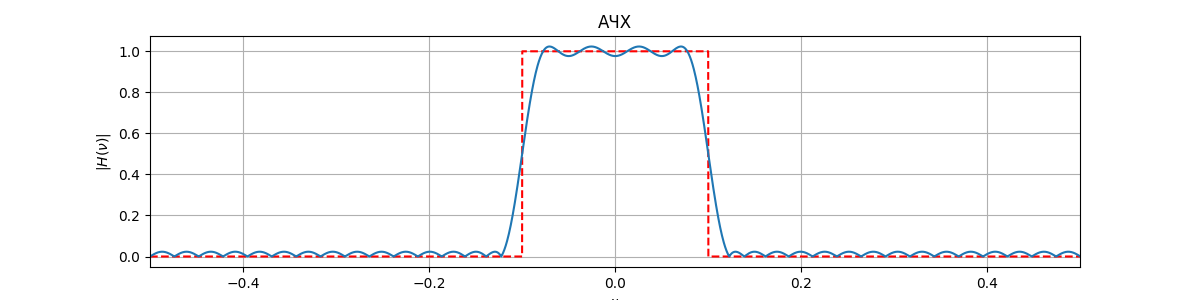

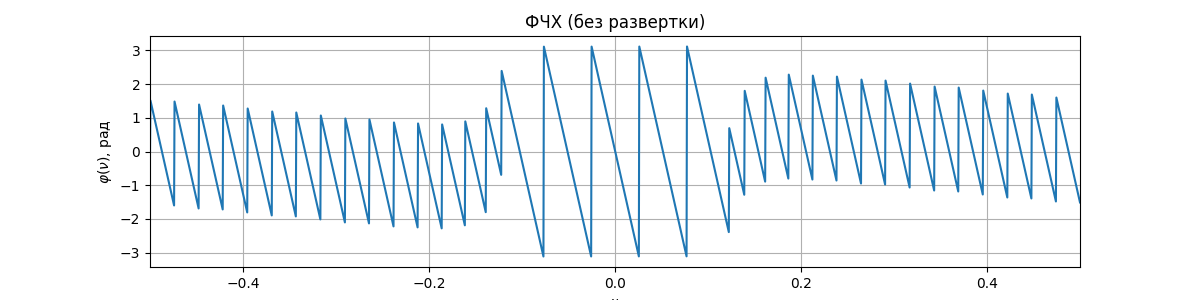

In [29]:
plot_filter_characteristics(h, fs, use_normalized_freq=True, unwrapping=False, ideal_cutoff_normalized=ideal_cutoff_normalized, ideal_k_pass=desired[0])
# сравните графики при разном выборе параметров use_normalized_freq и unwrapping

# use_normalized_freq отвечает за нормирование частот (частоты в кГц либо безразмерные)
# unwrapping отвечает за развертку фазы (убираются или нет скачки на 2pi)


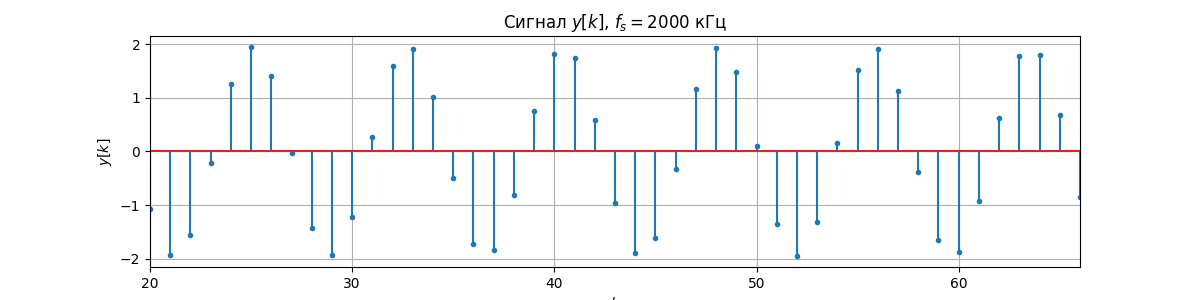

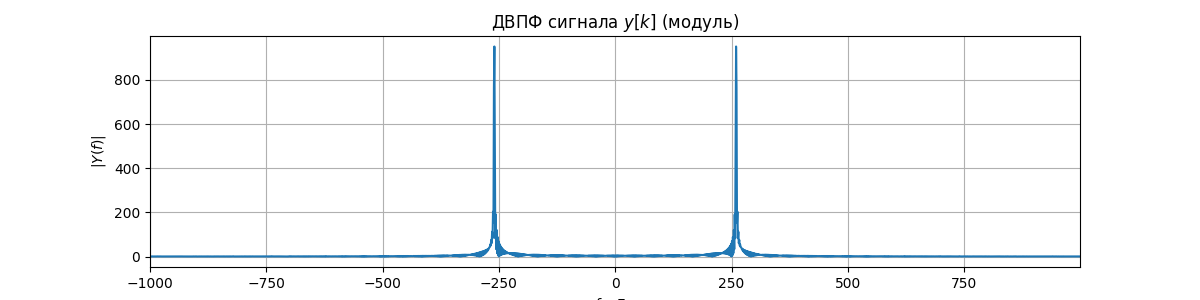

In [30]:
# Сигнал после передискретизации
y=signal.upfirdn(h, x, up=L, down=M)   # FIR filter
plot_signal_and_dtft(y, fs*L/M, signal_name="y", k_lim=[100*L/M, 330*L//M], use_normalized_freq=False)


## Задача 2.2. Система однократной передискретизации с рациональным шагом.

Промоделируйте работу системы однократной передискретизации с коэффицентом $L/M=5/2$ при подаче на ее вход сигнала из задачи 2.1.

1. Обоснуйте Ваш выбор фильтра для однократной передискретизации. Изобразите на графиках его АЧХ и ФЧХ.

2. Постройте графики, иллюстрирующие работу системы передискретизации во временной области:

* а) входного сигнала $x[k]$,

* б) выходного сигнала $y[k]$.

3. Постройте графики модуля ДВПФ последовательностей $x[k]$ и $y[k]$, иллюстрирующих работу системы передискретизации во частотной области.

4. Укажите шаг и частоту дискретизации выходного сигнала системы. 

In [31]:
# выбор коэффициентов
L = 5 # для децимации L = 1
M = 2


In [32]:
# чтение сигнала
fs, x = oscilloscope_file_read(file="Data/gen/6-2-1.txt", const_level=0)
print("частота дискретизации исходного сигнала", fs/1e6, " МГц.")
print("шаг дискретизации исходного сигнала", 1e6/fs, " мкс.")
print("частота дискретизации на выходе системы передискретизации", fs*L/M/1e6, " МГц.")
print("шаг дискретизации на выходе системы передискретизации", 1e6/(fs*L/M), " мкс.")


частота дискретизации исходного сигнала 10.0  МГц.
шаг дискретизации исходного сигнала 0.1  мкс.
частота дискретизации на выходе системы передискретизации 25.0  МГц.
шаг дискретизации на выходе системы передискретизации 0.04  мкс.


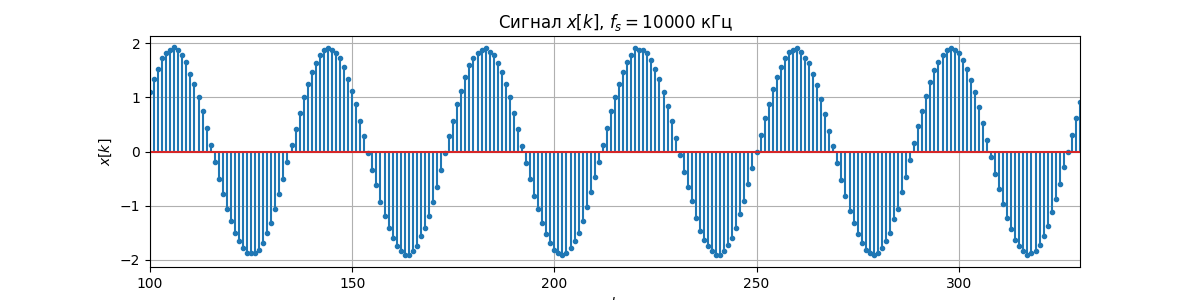

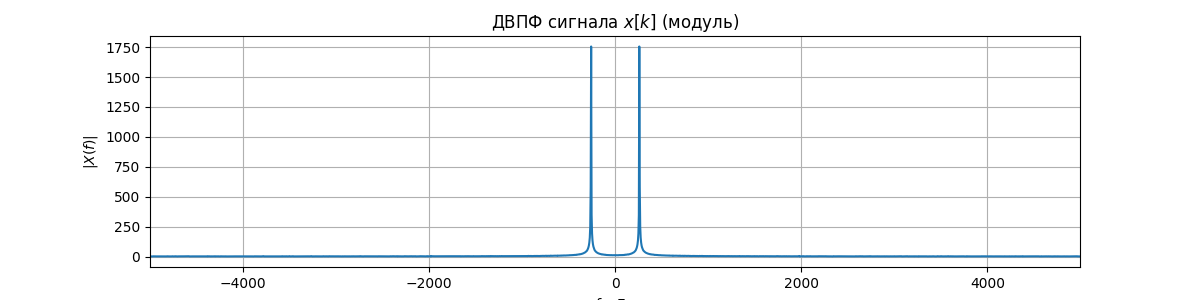

In [33]:
plot_signal_and_dtft(x, fs, signal_name="x", k_lim=[100, 330], use_normalized_freq=False)


In [34]:
# выбор фильтра
N=40
ideal_cutoff_normalized = min(1/(2*L), 1/(2*M))
nu1 = ideal_cutoff_normalized - 0.02 #0.05
nu2 = ideal_cutoff_normalized + 0.02 #0.05
bands = np.array([0, nu1, nu2, 0.5])
desired = np.array([L, 0])
weight = np.array([1, 1])
h = signal.remez(numtaps=N, bands=bands, desired=desired, weight=weight, fs=1)


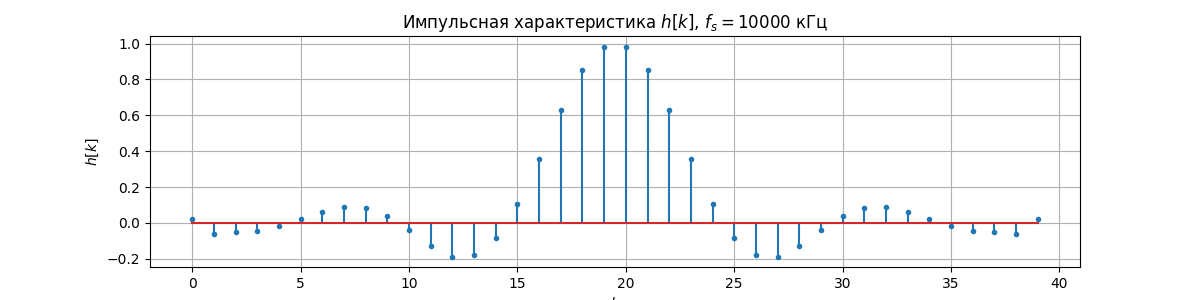

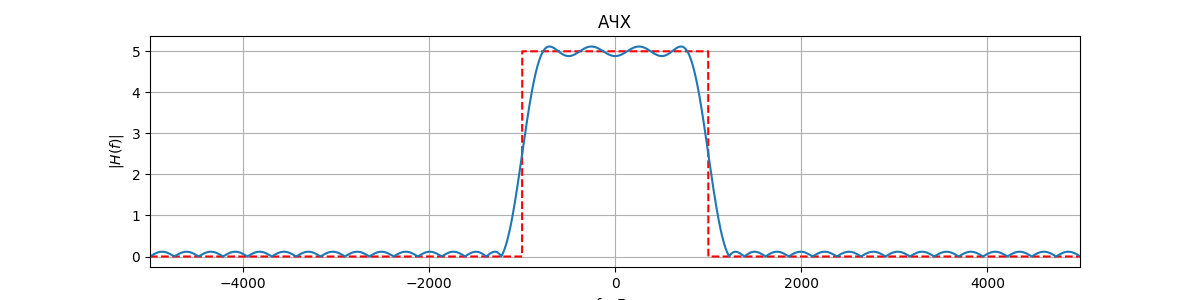

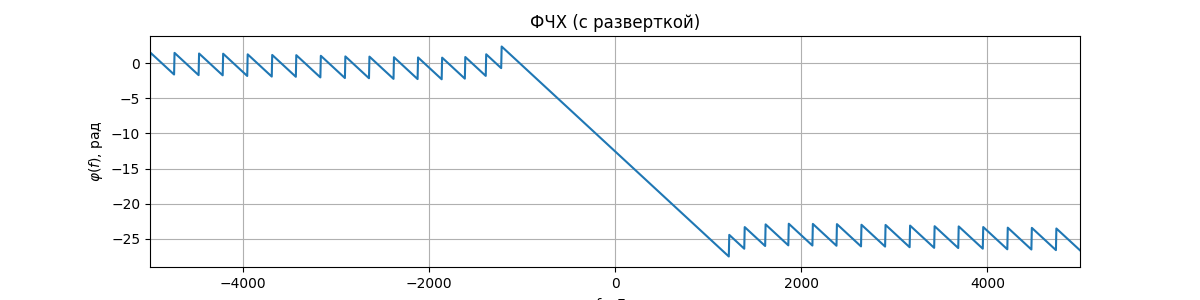

In [35]:
plot_filter_characteristics(h, fs, use_normalized_freq=False, unwrapping=True, ideal_cutoff_normalized=ideal_cutoff_normalized, ideal_k_pass=desired[0])
# сравните графики при разном выборе параметров use_normalized_freq и unwrapping

# use_normalized_freq отвечает за нормирование частот (частоты в кГц либо безразмерные)
# unwrapping отвечает за развертку фазы (убираются или нет скачки на 2pi)


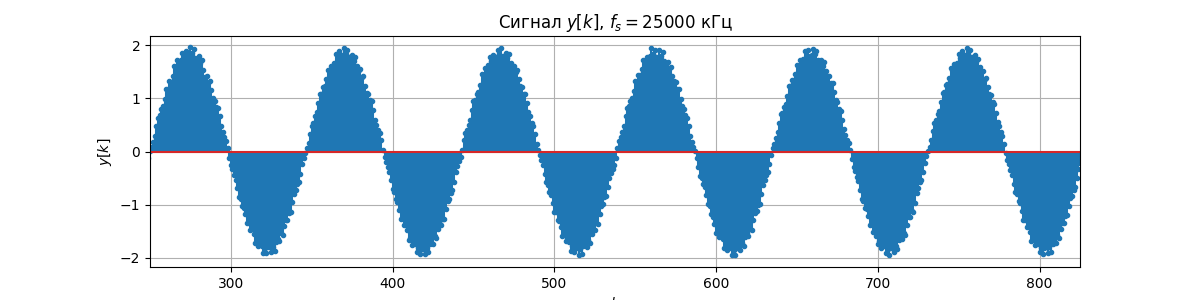

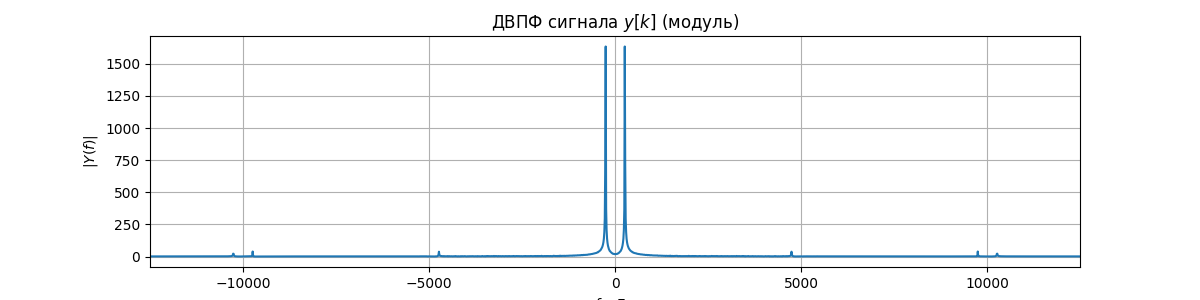

In [36]:
# Сигнал после передискретизации
y=signal.upfirdn(h, x, up=L, down=M)   # FIR filter
plot_signal_and_dtft(y, fs*L/M, signal_name="y", k_lim=[100*L/M, 330*L//M], use_normalized_freq=False)


#  Модуль 3. Особенности реализации многоскоростных систем.

## Задача 3.1. Полифазные структуры многоскоростных систем.

Промоделируйте работу системы однократной интерполяции с коэффицентом $L=4$ при подаче на ее вход сигнала из задачи 2.1 с помощью функции ``scipy.signal.resample_poly()``.


1. Постройте графики входного ($x[k]$) и выходного ($y[k]$) сигналов, и модулей их ДВПФ.

2. Изобразите схему данной полифазной структуры однократной интерполяции. 

3. Укажите шаг и частоту дискретизации выходного сигнала системы. 


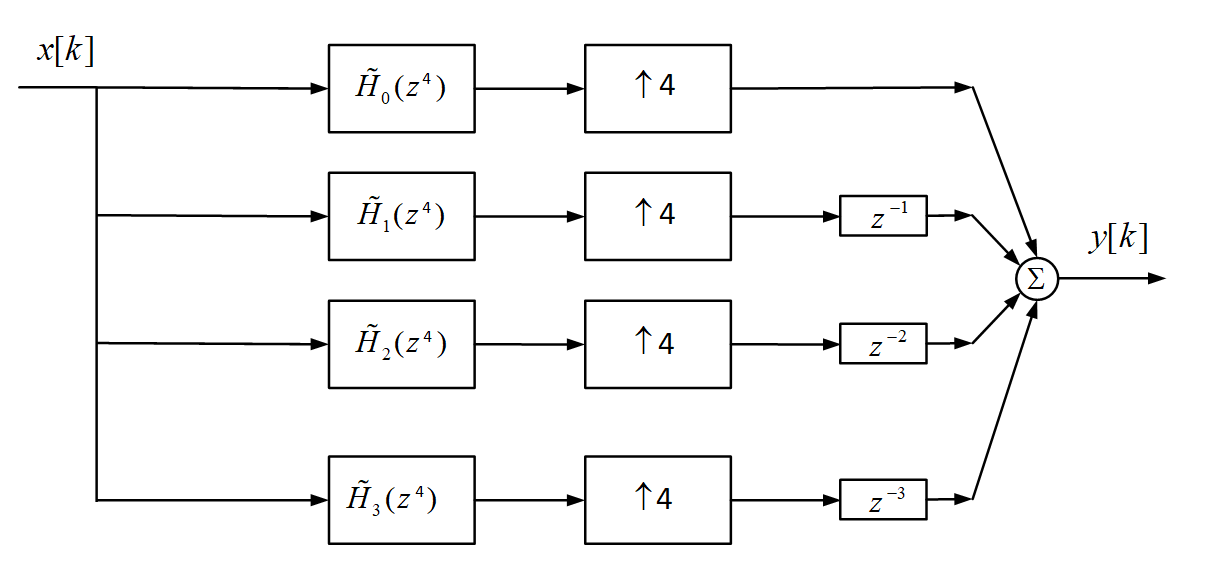

In [48]:
from IPython.display import Image
Image('polyphase_scheme.png')


частота дискретизации полифазных фильтров 10.0  МГц.
шаг дискретизации полифазных фильтров 0.1  мкс.
частота дискретизации выходного сигнала системы 40.0  МГц.
шаг дискретизации выходного сигнала системы 0.025  мкс.


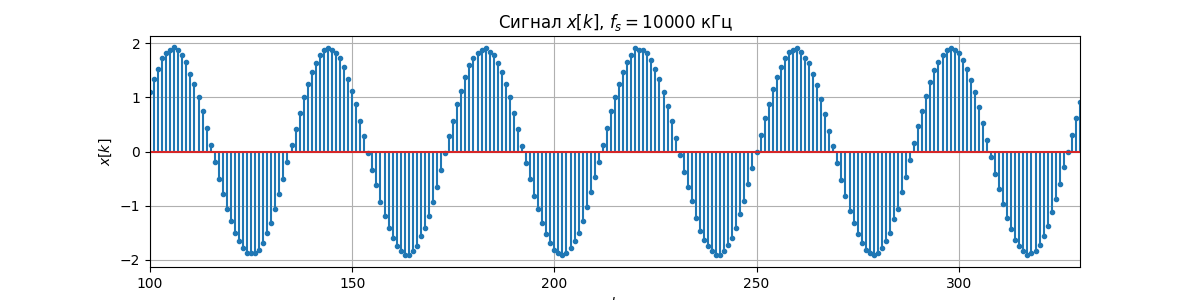

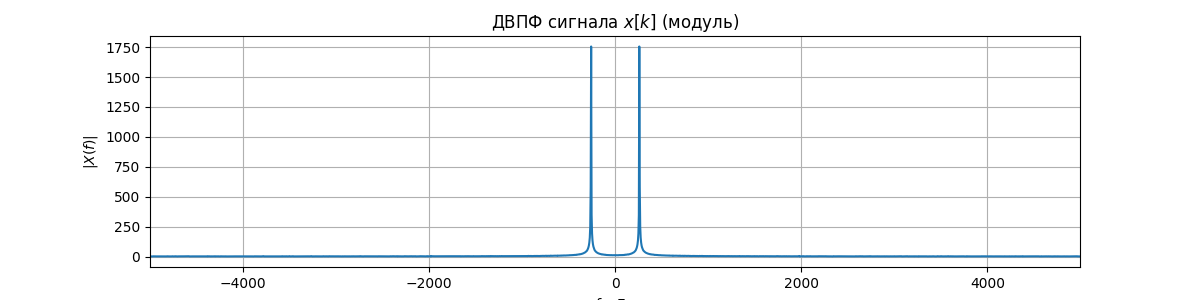

In [49]:
L=4
fs, x = oscilloscope_file_read(file="Data/gen/6-2-1.txt", const_level=0)
print("частота дискретизации полифазных фильтров", fs/1e6, " МГц.")
print("шаг дискретизации полифазных фильтров", 1e6/fs, " мкс.")
print("частота дискретизации выходного сигнала системы", fs*L/1e6, " МГц.")
print("шаг дискретизации выходного сигнала системы", 1e6/(fs*L), " мкс.")
#x=x[:100] # при необходимости можно ограничить длину последовательности
plot_signal_and_dtft(x, fs, signal_name="x", k_lim=[100, 330], use_normalized_freq=False)


In [50]:
N=40
ideal_cutoff_normalized = 1/(2*L)
nu1=ideal_cutoff_normalized-0.02 #0.05
nu2=ideal_cutoff_normalized+0.02 #0.05
bands = np.array([0, nu1, nu2, 0.5])
desired = np.array([L, 0])
weight = np.array([1, 1])
h = signal.remez(numtaps=N, bands=bands, desired=desired, weight=weight, fs=1)


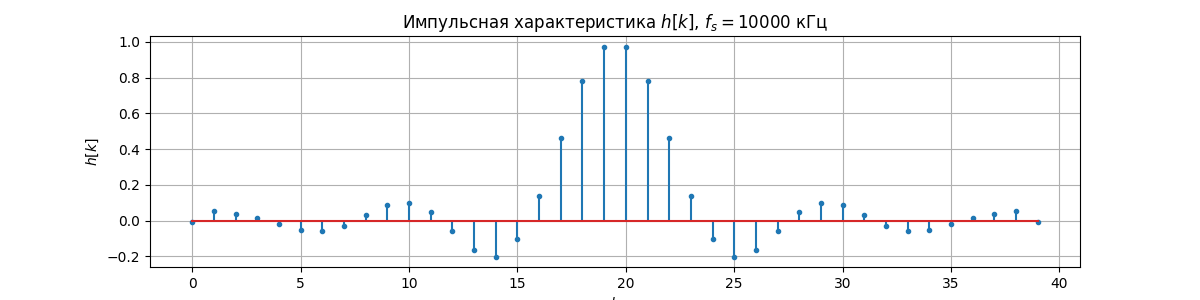

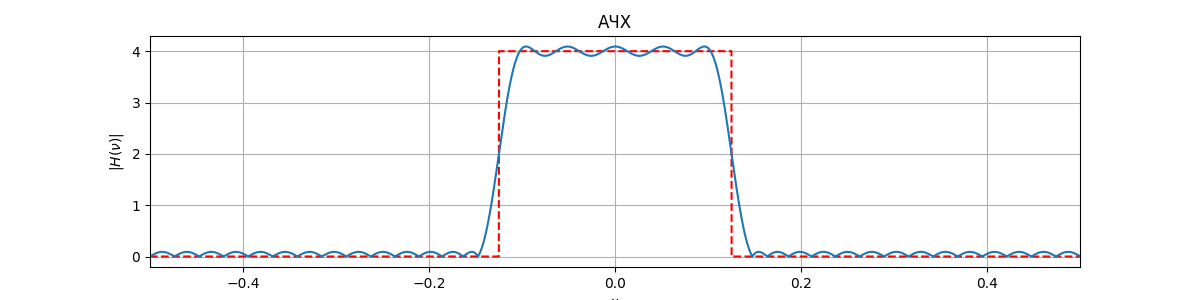

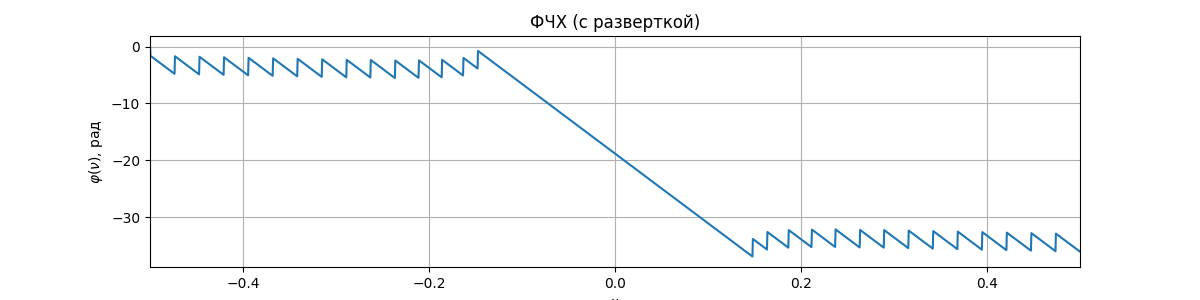

In [51]:
plot_filter_characteristics(h, fs, use_normalized_freq=True, unwrapping=True, ideal_cutoff_normalized=ideal_cutoff_normalized, ideal_k_pass=desired[0])
# сравните графики при разном выборе параметров use_normalized_freq и unwrapping

# use_normalized_freq отвечает за нормирование частот (частоты в кГц либо безразмерные)
# unwrapping отвечает за развертку фазы (убираются или нет скачки на 2pi)


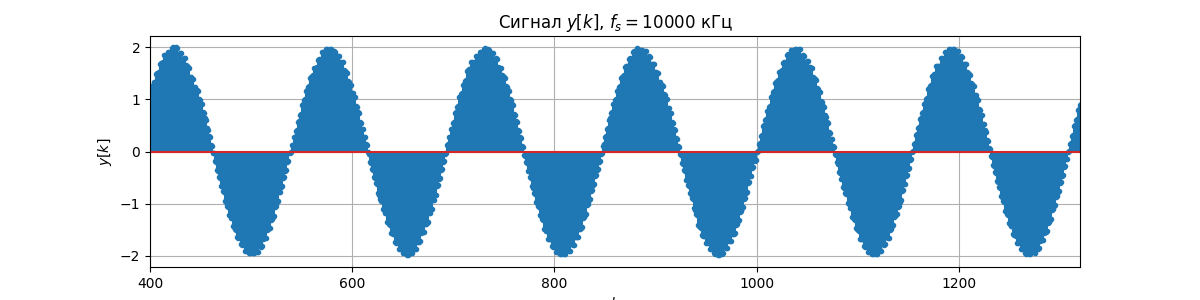

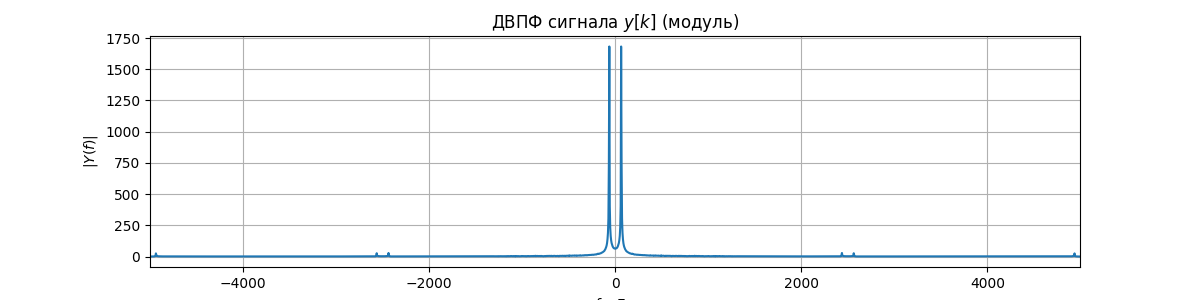

In [52]:
# расчет с помощью resample_poly
y = signal.resample_poly(x, up=L, down=1, window=h/L)
plot_signal_and_dtft(y, fs, signal_name="y", k_lim=[100*L, 330*L], use_normalized_freq=False)


In [53]:
G=int(N/L)
h_arr=np.zeros([L, G])
for m in range(L):
    h_arr[m]=np.array(h[m:N:L])


In [54]:
x_filtered=np.zeros([L, L*(x.size+G-1)])
for m in range(L):
    x_filtered[m][m::L]=signal.convolve(x, h_arr[m])
y = sum(x_filtered[:])


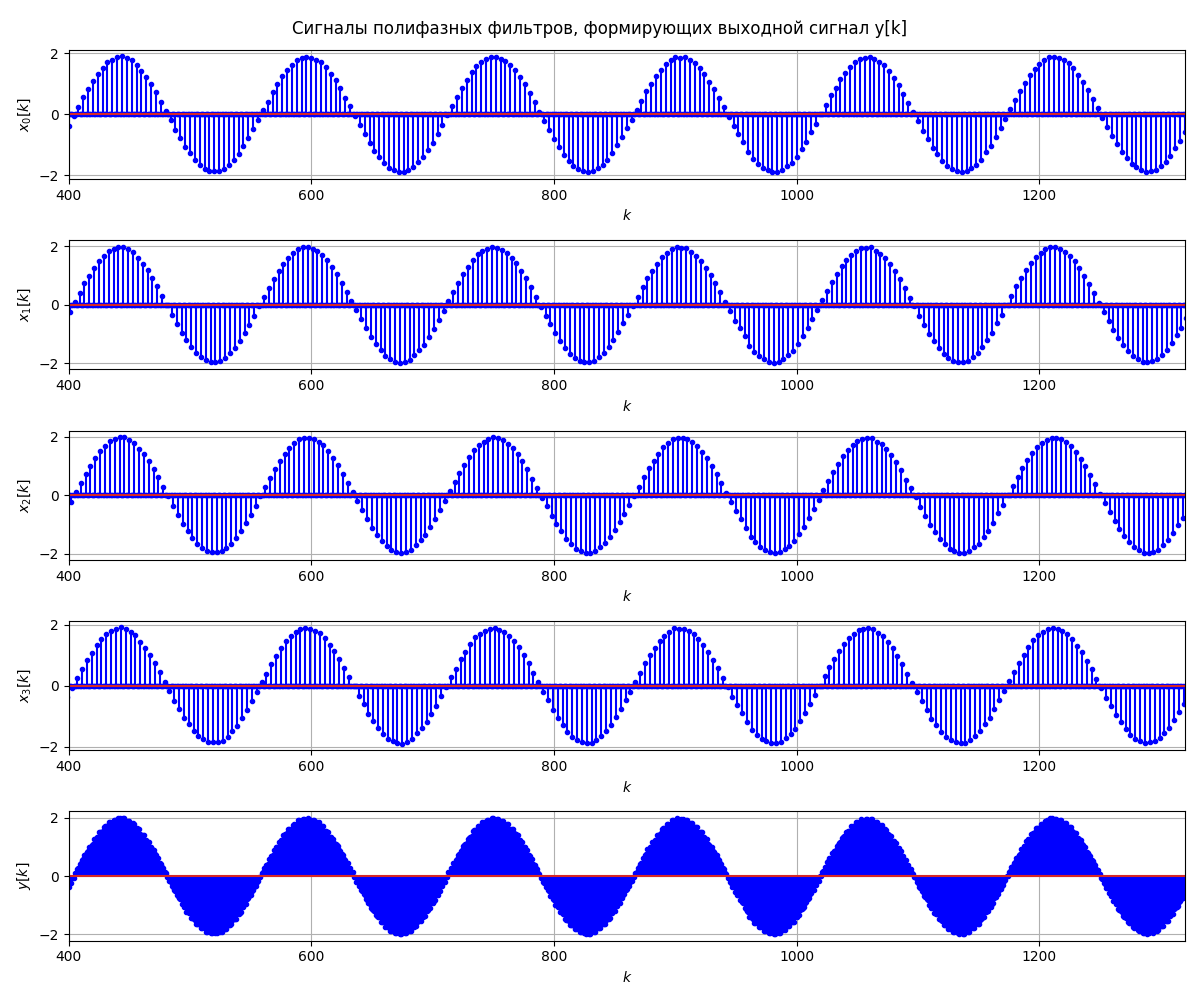

In [55]:
plt.figure(figsize=[12, 10])
k_lim = [100*L, 330*L]
k=np.arange(L*(x.size+G-1))
xsize=L*(x.size+G-1)
plt.suptitle("Сигналы полифазных фильтров, формирующих выходной сигнал y[k]")
for m in range(L):
    plt.subplot(L+1, 1, m+1)
    plt.stem(k, x_filtered[m], 'b', markerfmt='b.')
    plt.grid()
    # plt.xticks(k[::L])
    plt.xlim([(N-1)//2, xsize-(N-1)//2])
    plt.xlabel("$k$")
    plt.ylabel("$x_%i[k]$" %m)
    plt.xlim(k_lim)


plt.subplot(L+1, 1, L+1)
plt.stem(k, y, 'b', markerfmt='b.')
plt.grid()
# plt.xticks(k[::L])
plt.xlim([(N-1)//2, xsize-(N-1)//2])
plt.xlabel("$k$")
plt.ylabel("$y[k]$")
plt.xlim(k_lim)
plt.tight_layout()


## Задача 3.2. CIC-фильтры.

Постройте импульсную характеристику и АЧХ (в дБ) CIC-фильтра, состоящего из $Q$ последовательно соединенных каскадов, в каждом из которых длина импульсной характеристики равна $N$.


|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:---------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:------------:|:---------:|:----------------:|:----------:|:---------------:|:--------------:|:---------------:|:--------------:|
| $N$ |  16 |  16 |  16 |  16 |  16 |  12 |  12 |  12 |  12 |   12 |   20 |   20 |   20 |   20 |   20 |   32 |   32 |   32 |   32 |   32 |
| $Q$ |   3 |   4 |   5 |   6 |   7 |   3 |   4 |   5 |   6 |    7 |    3 |    4 |    5 |    6 |    7 |    3 |    4 |    5 |    6 |    7 |

Определите максимальный уровень пульсаций фильтра в полосе пропускания (по максимальному уровню бокового лепестка относительно главного). Постройте блок-схему одной из возможных реализаций даннного цифрового фильтра. 





Максимальный уровень пульсаций в полосе пропускания $\delta = -20 \cdot log(\frac{115089}{1073741824}) = 79.4$ дБ.

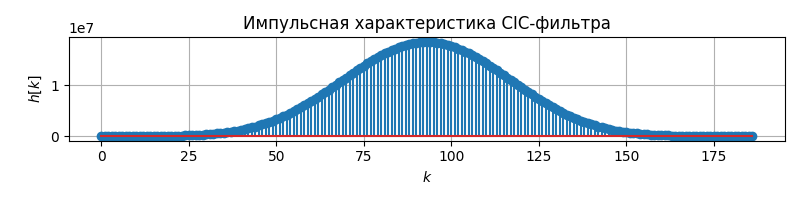

In [56]:
# настроить параметры
N = 32
Q = 6
h = np.ones(N)
for _ in range(Q-1):
    h = signal.convolve(np.ones(N), h)
plt.figure(figsize=[8, 2])
plt.stem(np.arange(h.size), h)
plt.xlabel("$k$")
plt.ylabel("$h[k]$")
plt.title("Импульсная характеристика CIC-фильтра")
plt.grid()
plt.tight_layout()


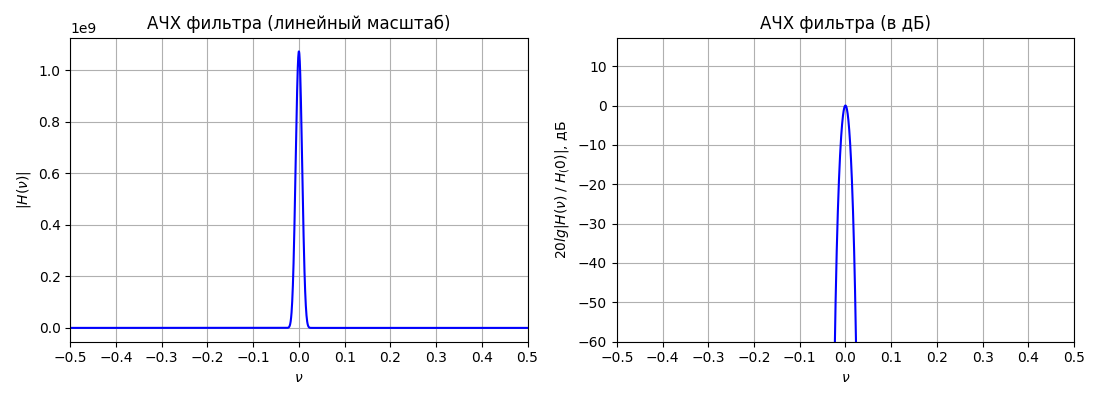

In [57]:
H=np.fft.fftshift(np.fft.fft(h, 2048))
nu=np.arange(H.size)/H.size-0.5
plt.figure(figsize=[11, 4])
plt.subplot(1, 2, 1)
plt.plot(nu, abs(H), 'b')
plt.xlim([-0.5, 0.5])
plt.xticks(np.arange(-0.5, 0.6, 0.1))
plt.xlabel("$\\nu$")
plt.ylabel("|$H(\\nu)|$")
plt.title("АЧХ фильтра (линейный масштаб)")
plt.grid()
plt.subplot(1, 2, 2)
with np.errstate(divide='ignore'):
    plt.plot(nu, 20*np.log10(abs(H)/max((abs(H)))), 'b')
plt.xlim([-0.5, 0.5])
plt.ylim(bottom=-60)
plt.xticks(np.arange(-0.5, 0.6, 0.1))
plt.xlabel("$\\nu$")
plt.ylabel("$20 lg|H(\\nu)\;/\;H_(0)|$, дБ")
plt.title("АЧХ фильтра (в дБ)")
plt.grid()
plt.tight_layout()


In [59]:
#Image('CIC-Q6-order.png')
